<a href="https://colab.research.google.com/github/24cse155rashmiranjanrout/ASSIGNMENT-1/blob/main/assignment07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier as descision
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
data = pd.read_csv('/content/balance-scale (1).csv')
print("first five records:")
print(data.head())
print("last five records:")
print(data.tail())


first five records:
  Class  L-Weight  L-Distance  R-Weight  R-Distance
0     B         1           1         1           1
1     R         1           1         1           2
2     R         1           1         1           3
3     R         1           1         1           4
4     R         1           1         1           5
last five records:
    Class  L-Weight  L-Distance  R-Weight  R-Distance
620     L         5           5         5           1
621     L         5           5         5           2
622     L         5           5         5           3
623     L         5           5         5           4
624     B         5           5         5           5


In [32]:
X=data.iloc[:,1:5]
Y=data.iloc[:,0]

In [37]:
print(X.head())
print(Y.head())

   L-Weight  L-Distance  R-Weight  R-Distance
0         1           1         1           1
1         1           1         1           2
2         1           1         1           3
3         1           1         1           4
4         1           1         1           5
0    B
1    R
2    R
3    R
4    R
Name: Class, dtype: object


In [36]:
class_count=Y.value_counts()
print(class_count)

Class
R    288
L    288
B     49
Name: count, dtype: int64


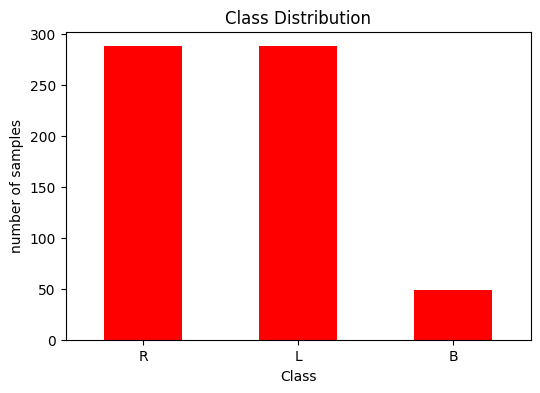

In [35]:
plt.figure(figsize=(6,4))
class_count.plot(kind='bar',color="red")
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('number of samples')
plt.xticks(rotation=0)
plt.show()


In [38]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [40]:
model = descision()
model.fit(X_train, Y_train)

DecisionTreeClassifier()

In [42]:
print("\nFeature Importances:")
for feature, importance in zip(X.columns, model.feature_importances_):
    print(f"{feature}: {importance:.4f}")


Feature Importances:
L-Weight: 0.2762
L-Distance: 0.2499
R-Weight: 0.2341
R-Distance: 0.2398


In [45]:
print("\nDecision Tree depth:")
print(model.get_depth())
print("\nNumber of leaf nodes:")
print(model.get_n_leaves())


Decision Tree depth:
11

Number of leaf nodes:
126


In [46]:
y_pred=model.predict(X_test)
print(y_pred)

['B' 'L' 'L' 'R' 'L' 'B' 'R' 'B' 'L' 'R' 'R' 'R' 'L' 'R' 'L' 'L' 'R' 'L'
 'B' 'L' 'B' 'R' 'R' 'L' 'L' 'L' 'R' 'L' 'L' 'L' 'L' 'R' 'R' 'L' 'R' 'L'
 'L' 'L' 'B' 'B' 'L' 'R' 'R' 'L' 'R' 'L' 'L' 'R' 'R' 'R' 'L' 'L' 'R' 'R'
 'L' 'L' 'L' 'R' 'L' 'R' 'L' 'L' 'R' 'R' 'L' 'L' 'R' 'R' 'L' 'L' 'R' 'R'
 'R' 'R' 'R' 'L' 'L' 'R' 'L' 'R' 'B' 'L' 'R' 'L' 'B' 'L' 'L' 'R' 'R' 'L'
 'L' 'L' 'R' 'L' 'L' 'R' 'R' 'R' 'R' 'R' 'L' 'L' 'B' 'R' 'L' 'L' 'L' 'R'
 'R' 'L' 'R' 'B' 'R' 'R' 'L' 'R' 'L' 'L' 'L' 'B' 'B' 'R' 'L' 'L' 'R']


In [52]:
cm=confusion_matrix(Y_test,y_pred)
print(cm)

[[ 0  8  3]
 [ 5 48  2]
 [ 8  4 47]]


In [48]:
accuracy=accuracy_score(y_pred,Y_test)
print(accuracy*100)

76.0


In [49]:
print("\n classification report:")
print(classification_report(Y_test,y_pred))


 classification report:
              precision    recall  f1-score   support

           B       0.00      0.00      0.00        11
           L       0.80      0.87      0.83        55
           R       0.90      0.80      0.85        59

    accuracy                           0.76       125
   macro avg       0.57      0.56      0.56       125
weighted avg       0.78      0.76      0.77       125



In [50]:
plt.figure(figsize=(6,5))



<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

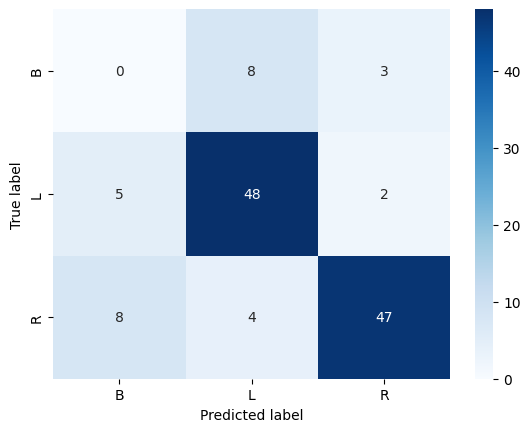

In [51]:
sns.heatmap(cm,
            annot=True,
            fmt="d",xticklabels=model.classes_,yticklabels=model.classes_,cmap=plt.cm.Blues)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()